Power    | Steps      | Runs     | Mean Payoff  | Failure Rate
-----------------------------------------------------------------
10^2     | 100        | 1000     | 0.3932       | 1.000        (0s)
10^3     | 1,000      | 1000     | 0.7775       | 0.700        (0s)
10^4     | 10,000     | 1000     | 0.9116       | 0.301        (0s)
10^5     | 100,000    | 1000     | 0.9398       | 0.229        (5s)
10^6     | 1,000,000  | 1000     | 0.9493       | 0.199        (50s)
10^7     | 10,000,000 | 100      | 0.9455       | 0.210        (51s)
10^8     | 100,000,000 | 100      | 0.9549       | 0.180        (508s)


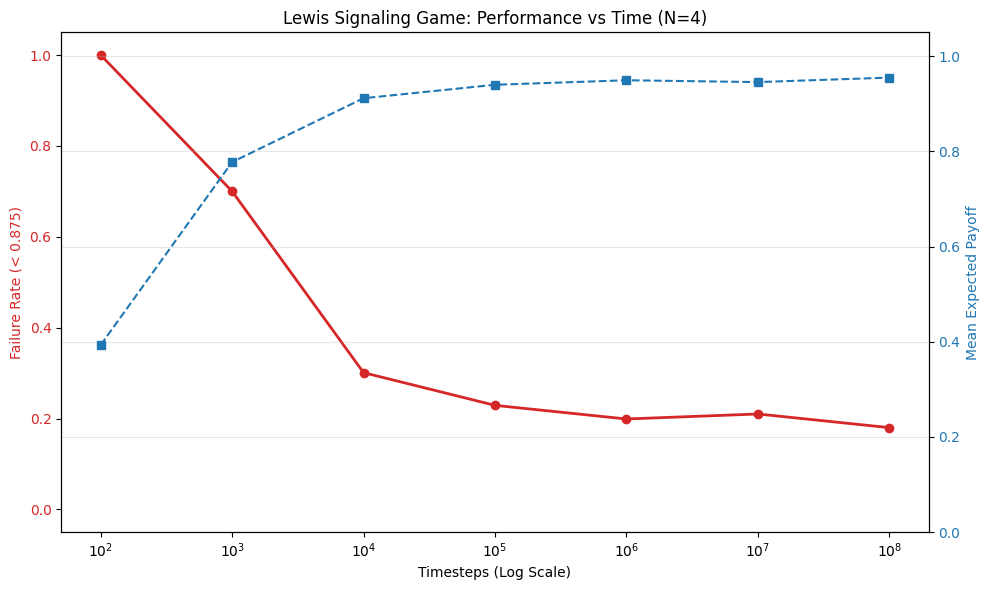

In [1]:
import numpy as np
from numba import njit
import matplotlib.pyplot as plt
import time
from datetime import datetime

"""
REPLICATION: Barrett (2006) - Basic Urn Models across Timestep Magnitudes
Threshold: 0.875 (User specified)
States/Signals/Acts: 8 (Standard for demonstrating pooling equilibria)
"""

# ---- Configuration ----
N = 4                # State space size
THRESHOLD = 0.875    # Success threshold
POWERS = [2, 3, 4, 5, 6, 7, 8]

@njit
def choose_from_urn(urn_row):
    """Simple weighted selection from an urn (Roth-Erev/Urn Learning)."""
    total_balls = urn_row.sum()
    r = np.random.random() * total_balls
    cumsum = 0.0
    for i in range(len(urn_row)):
        cumsum += urn_row[i]
        if r < cumsum:
            return i
    return len(urn_row) - 1

@njit
def run_single_simulation(n, timesteps):
    """
    Runs a single simulation of the basic Lewis signaling game.
    """
    # Initialize urns with 1 ball of each type
    sender_urns = np.ones((n, n), dtype=np.float64)
    receiver_urns = np.ones((n, n), dtype=np.float64)
    
    for t in range(timesteps):
        state = np.random.randint(0, n)
        signal = choose_from_urn(sender_urns[state])
        action = choose_from_urn(receiver_urns[signal])
        
        if action == state:
            sender_urns[state, signal] += 1.0
            receiver_urns[signal, action] += 1.0
            
    # Calculate analytical Expected Payoff (Success Rate) at the end of the run
    # This matches Barrett's methodology for determining if a run reached equilibrium
    expected_payoff = 0.0
    for s in range(n):
        for m in range(n):
            p_signal = sender_urns[s, m] / sender_urns[s].sum()
            p_action = receiver_urns[m, s] / receiver_urns[m].sum()
            expected_payoff += (1.0/n) * (p_signal * p_action)
            
    return expected_payoff

def main():
    print(f"{'Power':<8} | {'Steps':<10} | {'Runs':<8} | {'Mean Payoff':<12} | {'Failure Rate':<12}")
    print("-" * 65)
    
    all_summary_data = []

    for p in POWERS:
        timesteps = 10**p
        # 100 runs for 10^7 and 10^8, 1000 runs otherwise
        n_runs = 100 if p >= 7 else 1000
        
        payoffs = np.zeros(n_runs)
        start_time = time.time()
        
        # Run batch
        for i in range(n_runs):
            payoffs[i] = run_single_simulation(N, timesteps)
            
        elapsed = time.time() - start_time
        mean_payoff = np.mean(payoffs)
        failure_rate = np.sum(payoffs < THRESHOLD) / n_runs
        
        all_summary_data.append((p, mean_payoff, failure_rate))
        
        print(f"10^{p:<2}    | {timesteps:<10,} | {n_runs:<8} | {mean_payoff:<12.4f} | {failure_rate:<12.3f} ({int(elapsed)}s)")

    # Plotting the convergence over time
    powers_labels = [f"$10^{p}$" for p in POWERS]
    failure_rates = [d[2] for d in all_summary_data]
    mean_payoffs = [d[1] for d in all_summary_data]

    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.set_xlabel('Timesteps (Log Scale)')
    ax1.set_ylabel('Failure Rate (< 0.875)', color='tab:red')
    ax1.plot(POWERS, failure_rates, marker='o', color='tab:red', linewidth=2, label='Failure Rate')
    ax1.tick_params(axis='y', labelcolor='tab:red')
    ax1.set_ylim(-0.05, 1.05)

    ax2 = ax1.twinx()
    ax2.set_ylabel('Mean Expected Payoff', color='tab:blue')
    ax2.plot(POWERS, mean_payoffs, marker='s', color='tab:blue', linestyle='--', label='Mean Payoff')
    ax2.tick_params(axis='y', labelcolor='tab:blue')
    ax2.set_ylim(0, 1.05)

    plt.title(f'Lewis Signaling Game: Performance vs Time (N={N})')
    plt.xticks(POWERS, powers_labels)
    fig.tight_layout()
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":
    # Initial "Warmup" for Numba JIT
    run_single_simulation(2, 10)
    main()